In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import time
from sklearn.metrics import classification_report
from torchmetrics.classification import MulticlassAccuracy, MulticlassROC, MulticlassConfusionMatrix
from ignite.engine import Engine, Events
from ignite.handlers import EarlyStopping
from ignite.metrics import Loss

/opt/anaconda3/lib/python3.12/site-packages/ignite/handlers/checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torchinfo import summary
from collections import Counter

1. Load, preprocess, analyze, visualize the dataset and make it ready for training.

In [3]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [4]:
dataset = torchvision.datasets.ImageFolder(root='./datasets/cnn_dataset')

In [5]:
len(dataset)

100800

In [6]:
len(dataset.classes)

36

In [7]:
train_size = int(0.85 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_dataset, val_dataset = random_split(train_dataset, [train_size - test_size, test_size])

In [8]:
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

In [9]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

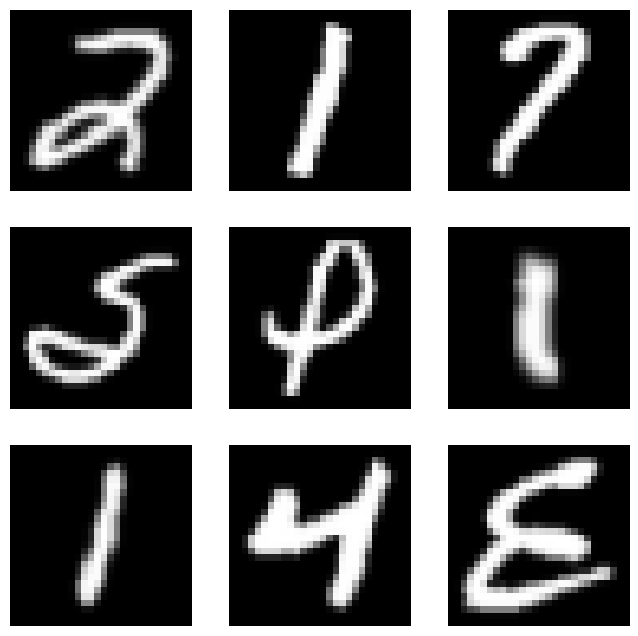

In [10]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.axis("off")
    plt.imshow(img.squeeze().numpy(), cmap="gray")
plt.show()

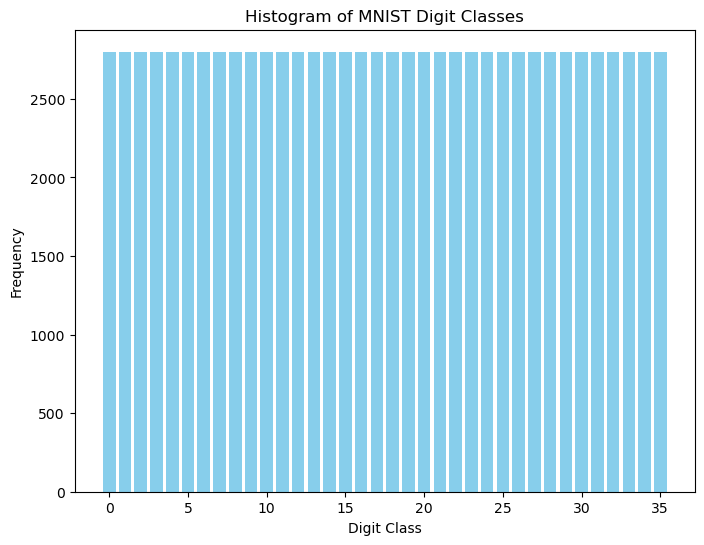

In [11]:
labels = [label for _, label in dataset]
class_counts = Counter(labels)

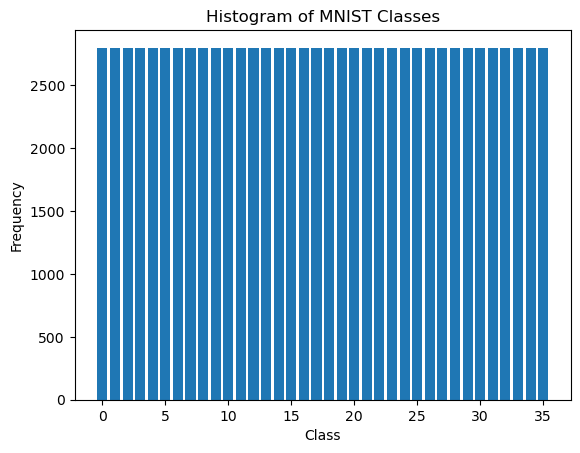

In [17]:
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.title("Histogram of MNIST Classes")
plt.show()

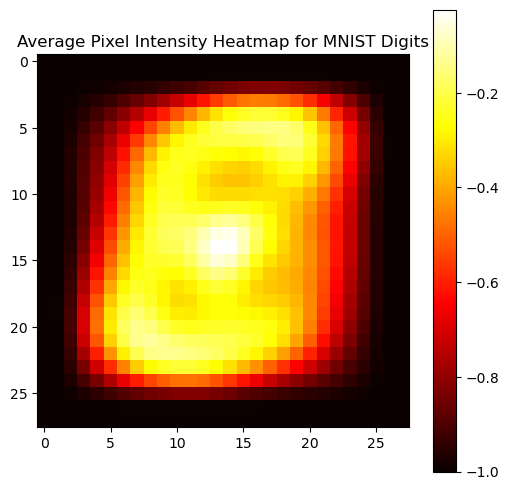

In [12]:
mean_image = torch.zeros((28, 28))
for img, _ in dataset:
    mean_image += img.squeeze()
mean_image /= len(dataset)

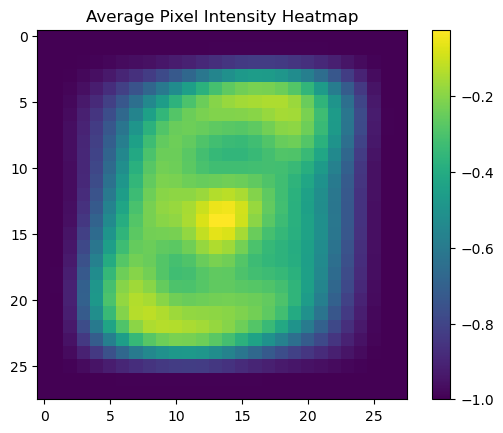

In [16]:
plt.imshow(mean_image, interpolation='nearest')
plt.colorbar()
plt.title("Average Pixel Intensity Heatmap")
plt.show()

2. Build and train a basic CNN 
- Input neurons: 1
- Output neurons: 36
- Activation function used for the hidden layers: ReLU
- Activation function used for the output layer: Softmax
- The number of hidden layers: 3
- The size of each hidden layer: 32, 64, 128
- Pooling layer: Max pool layer

In [11]:
class BasicCNN(nn.Module):
    def __init__(self):
        super(BasicCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 36)

    
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [13]:
basic_cnn = BasicCNN()
summary(basic_cnn, input_size=(32, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
BasicCNN                                 [32, 36]                  --
├─Conv2d: 1-1                            [32, 32, 28, 28]          320
├─MaxPool2d: 1-2                         [32, 32, 14, 14]          --
├─Conv2d: 1-3                            [32, 64, 14, 14]          18,496
├─MaxPool2d: 1-4                         [32, 64, 7, 7]            --
├─Linear: 1-5                            [32, 128]                 401,536
├─Linear: 1-6                            [32, 36]                  4,644
Total params: 424,996
Trainable params: 424,996
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 137.03
Input size (MB): 0.10
Forward/backward pass size (MB): 9.68
Params size (MB): 1.70
Estimated Total Size (MB): 11.48

In [14]:
loss_function = nn.CrossEntropyLoss()
PATH = "best_loss_part3.pt"

In [15]:
def train_val_model(model, optimizer):
    train_accuracy_hist = []
    train_loss_hist = []
    val_accuracy_hist = []
    val_loss_hist = []
    best_loss = float('inf')
    start_time = time.time()
    
    for epoch in range(10):
        # train
        model.train()
        train_loss = 0.0
        train_accuracy_metric = MulticlassAccuracy(num_classes=36)
        for train_inputs, train_labels in train_loader:
            optimizer.zero_grad()
            outputs = model(train_inputs)
            loss = loss_function(outputs, train_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            predicted = torch.argmax(outputs.data, 1)
            train_accuracy_metric.update(predicted, train_labels)
        train_accuracy_hist.append(train_accuracy_metric.compute().item())
        train_loss_hist.append(train_loss/len(train_loader))
  
        # validation
        model.eval()
        val_loss = 0.0
        val_accuracy_metric = MulticlassAccuracy(num_classes=36)
        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_outputs = model(val_inputs)
                val_loss += loss_function(val_outputs, val_labels).item()
                predicted = torch.argmax(val_outputs.data, 1)
                val_accuracy_metric.update(predicted, val_labels)
        val_accuracy_hist.append(val_accuracy_metric.compute().item())
        val_loss_hist.append(val_loss/len(val_loader))
    
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), PATH)
        print(f"Epoch [{epoch + 1}/{10}], Loss: {val_loss / len(train_loader):.4f}")
            
    train_time = time.time() - start_time
    return {'train_accuracy_hist': train_accuracy_hist, 'train_loss_hist': train_loss_hist, 'val_accuracy_hist': val_accuracy_hist, 'val_loss_hist': val_loss_hist, 'train_time': train_time}

In [16]:
optimizer = optim.Adam(basic_cnn.parameters(), lr=0.001)
result = train_val_model(basic_cnn, optimizer)

Epoch [1/10], Loss: 0.0779
Epoch [2/10], Loss: 0.0685
Epoch [3/10], Loss: 0.0602
Epoch [4/10], Loss: 0.0615
Epoch [5/10], Loss: 0.0609
Epoch [6/10], Loss: 0.0663
Epoch [7/10], Loss: 0.0633
Epoch [8/10], Loss: 0.0690
Epoch [9/10], Loss: 0.0702
Epoch [10/10], Loss: 0.0729


In [17]:
def test_model(model):
    # test
    model.load_state_dict(torch.load(PATH, weights_only=True))
    accuracy_metric = MulticlassAccuracy(num_classes=36)
    test_loss = 0
    with torch.no_grad():
        for test_inputs, test_labels in test_loader:
            test_outputs = model(test_inputs)
            loss = loss_function(test_outputs, test_labels)
            test_loss += loss.item()
            predicted = torch.argmax(test_outputs.data, dim=1)
            accuracy_metric.update(predicted, test_labels)

    print(f'Accuracy: {accuracy_metric.compute().item():.4f}, Test Loss: {test_loss / len(test_loader):.4f}')

In [18]:
basic_cnn = BasicCNN()
test_model(basic_cnn)

Accuracy: 0.9036, Test Loss: 0.2686


Improvement methods

In [19]:
# Learning rate scheduler
PATH = "best_loss_part3_sch.pt"

In [20]:
def sch_train_val_model(model, optimizer, sch_model):
    train_accuracy_hist = []
    train_loss_hist = []
    val_accuracy_hist = []
    val_loss_hist = []
    best_loss = float('inf')
    start_time = time.time()
    
    for epoch in range(10):
        # train
        model.train()
        train_loss = 0.0
        train_accuracy_metric = MulticlassAccuracy(num_classes=36)
        for train_inputs, train_labels in train_loader:
            optimizer.zero_grad()
            outputs = model(train_inputs)
            loss = loss_function(outputs, train_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            predicted = torch.argmax(outputs.data, 1)
            train_accuracy_metric.update(predicted, train_labels)
        train_accuracy_hist.append(train_accuracy_metric.compute().item())
        train_loss_hist.append(train_loss/len(train_loader))
  
        # validation
        model.eval()
        val_loss = 0.0
        val_accuracy_metric = MulticlassAccuracy(num_classes=36)
        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_outputs = model(val_inputs)
                val_loss += loss_function(val_outputs, val_labels).item()
                predicted = torch.argmax(val_outputs.data, 1)
                val_accuracy_metric.update(predicted, val_labels)
        val_accuracy_hist.append(val_accuracy_metric.compute().item())
        val_loss_hist.append(val_loss/len(val_loader))
        scheduler.step(val_loss)
        print(f"Epoch {epoch+1}, Learning Rate: {scheduler.get_last_lr()[0]:.6f}")
    
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), PATH)
        print(f"Epoch [{epoch + 1}/{10}], Loss: {val_loss / len(train_loader):.4f}")
            
    train_time = time.time() - start_time
    return {'train_accuracy_hist': train_accuracy_hist, 'train_loss_hist': train_loss_hist, 'val_accuracy_hist': val_accuracy_hist, 'val_loss_hist': val_loss_hist, 'train_time': train_time}

In [21]:
sch_cnn = BasicCNN()
sch_optimizer = optim.Adam(sch_cnn.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(sch_optimizer, 'min', patience=2)
sch_result = sch_train_val_model(sch_cnn, sch_optimizer, scheduler)

Epoch 1, Learning Rate: 0.001000
Epoch [1/10], Loss: 0.0759
Epoch 2, Learning Rate: 0.001000
Epoch [2/10], Loss: 0.0676
Epoch 3, Learning Rate: 0.001000
Epoch [3/10], Loss: 0.0621
Epoch 4, Learning Rate: 0.001000
Epoch [4/10], Loss: 0.0633
Epoch 5, Learning Rate: 0.001000
Epoch [5/10], Loss: 0.0637
Epoch 6, Learning Rate: 0.000100
Epoch [6/10], Loss: 0.0631
Epoch 7, Learning Rate: 0.000100
Epoch [7/10], Loss: 0.0603
Epoch 8, Learning Rate: 0.000100
Epoch [8/10], Loss: 0.0607
Epoch 9, Learning Rate: 0.000100
Epoch [9/10], Loss: 0.0633
Epoch 10, Learning Rate: 0.000010
Epoch [10/10], Loss: 0.0645


In [22]:
sch_cnn = BasicCNN()
test_model(sch_cnn)

Accuracy: 0.9155, Test Loss: 0.2640


In [23]:
# normalization
PATH = "best_loss_part3_bn.pt"

In [24]:
class NormalizationCNN(nn.Module):
    def __init__(self):
        super(NormalizationCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(1600, 128)
        self.fc2 = nn.Linear(128, 36)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.pool(torch.relu(x))
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.pool(torch.relu(x))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [25]:
bn_cnn = NormalizationCNN()
bn_optimizer = optim.Adam(bn_cnn.parameters(), lr=0.001)
bn_result = train_val_model(bn_cnn, bn_optimizer)

Epoch [1/10], Loss: 0.0711
Epoch [2/10], Loss: 0.0657
Epoch [3/10], Loss: 0.0639
Epoch [4/10], Loss: 0.0603
Epoch [5/10], Loss: 0.0584
Epoch [6/10], Loss: 0.0603
Epoch [7/10], Loss: 0.0603
Epoch [8/10], Loss: 0.0620
Epoch [9/10], Loss: 0.0624
Epoch [10/10], Loss: 0.0637


In [26]:
summary(bn_cnn, input_size=(32, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
NormalizationCNN                         [32, 36]                  --
├─Conv2d: 1-1                            [32, 32, 26, 26]          320
├─BatchNorm2d: 1-2                       [32, 32, 26, 26]          64
├─MaxPool2d: 1-3                         [32, 32, 13, 13]          --
├─Conv2d: 1-4                            [32, 64, 11, 11]          18,496
├─BatchNorm2d: 1-5                       [32, 64, 11, 11]          128
├─MaxPool2d: 1-6                         [32, 64, 5, 5]            --
├─Linear: 1-7                            [32, 128]                 204,928
├─Linear: 1-8                            [32, 36]                  4,644
Total params: 228,580
Trainable params: 228,580
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 85.25
Input size (MB): 0.10
Forward/backward pass size (MB): 15.08
Params size (MB): 0.91
Estimated Total Size (MB): 16.10

In [27]:
def bn_test_model(model):
    # test
    model.load_state_dict(torch.load(PATH))
    accuracy_metric = MulticlassAccuracy(num_classes=36)
    test_loss = 0
    with torch.no_grad():
        for test_inputs, test_labels in test_loader:
            test_outputs = model(test_inputs)
            loss = loss_function(test_outputs, test_labels)
            test_loss += loss.item()
            predicted = torch.argmax(test_outputs.data, dim=1)
            accuracy_metric.update(predicted, test_labels)

    print(f'Accuracy: {accuracy_metric.compute().item():.4f}, Test Loss: {test_loss / len(test_loader):.4f}')

In [28]:
bn_cnn = NormalizationCNN()
bn_test_model(bn_cnn)

/var/folders/nf/b08l0pm103v6j8bhb45qf72w0000gn/T/ipykernel_1638/2166887428.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(PATH))


Accuracy: 0.9053, Test Loss: 0.2689


In [61]:
# Early stopping
PATH = "best_loss_part3_es.pt"

In [62]:
def score_function(engine):
    val_loss = engine.state.metrics['val_loss']
    return -val_loss

In [63]:
es_cnn = BasicCNN()
es_optimizer = optim.Adam(es_cnn.parameters(), lr=0.001)
es_accuracy_hist = []
best_val_loss = float('inf')
best_model_state = None
es_accuracy_metric = MulticlassAccuracy(num_classes=36)

In [64]:
def train_en(engine, batch):
    es_cnn.train()
    es_optimizer.zero_grad()
    x, y = batch
    y_pred = es_cnn(x)
    loss = loss_function(y_pred, y)
    loss.backward()
    es_optimizer.step()
    return loss.item()

In [65]:
def validation_en(engine, batch):
    es_cnn.eval()
    with torch.no_grad():
        x, y = batch
        y_output = es_cnn(x)
        return y_output, y

In [66]:
trainer = Engine(train_en)
evaluator = Engine(validation_en)
Loss(loss_function).attach(evaluator, "val_loss")
handler = EarlyStopping(patience=5, score_function=score_function, trainer=trainer)
evaluator.add_event_handler(Events.COMPLETED, handler)

In [67]:
@trainer.on(Events.EPOCH_COMPLETED)
def run_validation():
    global best_val_loss, best_model_state
    evaluator.run(val_loader)
    y_preds, y_true = [], []
    for batch in val_loader:
        x, y = batch
        y_pred = es_cnn(x)
        y_preds.append(y_pred)
        y_true.append(y)
    y_preds = torch.cat(y_preds)
    y_true = torch.cat(y_true)
    accuracy = es_accuracy_metric(y_preds, y_true).item()
    es_accuracy_hist.append(accuracy)
    val_loss = evaluator.state.metrics['val_loss']
    print(f'Accuracy: {accuracy:.4f}, Loss: {val_loss:.4f}')
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = es_cnn.state_dict()

@trainer.on(Events.COMPLETED)
def save_best_model():
    global best_model_state
    torch.save(best_model_state, PATH)
    
train_state = trainer.run(train_loader, max_epochs=100)

Accuracy: 0.8742, Loss: 0.3446
Accuracy: 0.8948, Loss: 0.2965
Accuracy: 0.8915, Loss: 0.2996
Accuracy: 0.8990, Loss: 0.2961
Accuracy: 0.9005, Loss: 0.2869
Accuracy: 0.9012, Loss: 0.2932
Accuracy: 0.8975, Loss: 0.3095
Accuracy: 0.9000, Loss: 0.3170
Accuracy: 0.8991, Loss: 0.3331


2024-11-05 10:59:58,467 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Accuracy: 0.8940, Loss: 0.3555


In [68]:
es_cnn = BasicCNN()
test_model(es_cnn)

Accuracy: 0.8987, Test Loss: 0.3442


Final model
- with learning rate scheduler
- with batch normalization

In [80]:
FINAL_PATH = "heejuhwa_assignment2_part3.pt"

In [18]:
class FinalCNN(nn.Module):
    def __init__(self):
        super(FinalCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(1600, 128)
        self.fc2 = nn.Linear(128, 36)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.pool(torch.relu(x))
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.pool(torch.relu(x))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [130]:
def final_train_val_model(model, optimizer, sch_model):
    train_accuracy_hist = []
    train_loss_hist = []
    val_accuracy_hist = []
    val_loss_hist = []
    best_loss = float('inf')
    start_time = time.time()
    
    for epoch in range(10):
        # train
        model.train()
        train_loss = 0.0
        train_accuracy_metric = MulticlassAccuracy(num_classes=36)
        for train_inputs, train_labels in train_loader:
            optimizer.zero_grad()
            outputs = model(train_inputs)
            loss = loss_function(outputs, train_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            predicted = torch.argmax(outputs.data, 1)
            train_accuracy_metric.update(predicted, train_labels)
        train_accuracy_hist.append(train_accuracy_metric.compute().item())
        train_loss_hist.append(train_loss/len(train_loader))
  
        # validation
        model.eval()
        val_loss = 0.0
        val_accuracy_metric = MulticlassAccuracy(num_classes=36)
        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_outputs = model(val_inputs)
                val_loss += loss_function(val_outputs, val_labels).item()
                predicted = torch.argmax(val_outputs.data, 1)
                val_accuracy_metric.update(predicted, val_labels)
        val_accuracy_hist.append(val_accuracy_metric.compute().item())
        val_loss_hist.append(val_loss/len(val_loader))
        scheduler.step(val_loss)
        print(f"Epoch {epoch+1}, Learning Rate: {scheduler.get_last_lr()[0]:.6f}")
    
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), FINAL_PATH)
        print(f"Epoch [{epoch + 1}/{10}], Loss: {val_loss / len(train_loader):.4f}")
            
    train_time = time.time() - start_time
    return {'train_accuracy_hist': train_accuracy_hist, 'train_loss_hist': train_loss_hist, 'val_accuracy_hist': val_accuracy_hist, 'val_loss_hist': val_loss_hist, 'train_time': train_time}

In [142]:
def final_test_model(model):
    # test
    model.load_state_dict(torch.load(FINAL_PATH))
    accuracy_metric = MulticlassAccuracy(num_classes=36)
    all_labels = torch.tensor([])
    all_outputs = torch.tensor([])
    all_preds = torch.tensor([])
    test_loss = 0
    with torch.no_grad():
        for test_inputs, test_labels in test_loader:
            test_outputs = model(test_inputs)
            loss = loss_function(test_outputs, test_labels)
            test_loss += loss.item()
            predicted = torch.argmax(test_outputs.data, dim=1)
            all_labels = torch.cat((all_labels, test_labels), dim=0)
            all_outputs = torch.cat((all_outputs, test_outputs), dim=0)
            all_preds = torch.cat((all_preds, predicted), dim=0)
            accuracy_metric.update(predicted, test_labels)
    test_loss = test_loss/len(test_loader)
    
    print(f'Accuracy: {accuracy_metric.compute().item():.4f}, Test Loss: {test_loss:.4f}')
    return {'test_accuracy': accuracy_metric.compute().item(), 'test_loss': test_loss, 'test_labels': all_labels, 'test_predicted': all_preds, 'test_outputs': all_outputs}

In [19]:
final_cnn = FinalCNN()
summary(final_cnn, input_size=(32, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
FinalCNN                                 [32, 36]                  --
├─Conv2d: 1-1                            [32, 32, 26, 26]          320
├─BatchNorm2d: 1-2                       [32, 32, 26, 26]          64
├─MaxPool2d: 1-3                         [32, 32, 13, 13]          --
├─Conv2d: 1-4                            [32, 64, 11, 11]          18,496
├─BatchNorm2d: 1-5                       [32, 64, 11, 11]          128
├─MaxPool2d: 1-6                         [32, 64, 5, 5]            --
├─Linear: 1-7                            [32, 128]                 204,928
├─Linear: 1-8                            [32, 36]                  4,644
Total params: 228,580
Trainable params: 228,580
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 85.25
Input size (MB): 0.10
Forward/backward pass size (MB): 15.08
Params size (MB): 0.91
Estimated Total Size (MB): 16.10

In [132]:
final_optimizer = optim.Adam(final_cnn.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(final_optimizer, 'min', patience=2)
final_result = final_train_val_model(final_cnn, final_optimizer, scheduler)

Epoch 1, Learning Rate: 0.001000
Epoch [1/10], Loss: 0.0778
Epoch 2, Learning Rate: 0.001000
Epoch [2/10], Loss: 0.0688
Epoch 3, Learning Rate: 0.001000
Epoch [3/10], Loss: 0.0642
Epoch 4, Learning Rate: 0.001000
Epoch [4/10], Loss: 0.0586
Epoch 5, Learning Rate: 0.001000
Epoch [5/10], Loss: 0.0611
Epoch 6, Learning Rate: 0.001000
Epoch [6/10], Loss: 0.0575
Epoch 7, Learning Rate: 0.001000
Epoch [7/10], Loss: 0.0596
Epoch 8, Learning Rate: 0.001000
Epoch [8/10], Loss: 0.0626
Epoch 9, Learning Rate: 0.000100
Epoch [9/10], Loss: 0.0646
Epoch 10, Learning Rate: 0.000100
Epoch [10/10], Loss: 0.0571


In [143]:
final_cnn = FinalCNN()
final_test_result = final_test_model(final_cnn)

/var/folders/nf/b08l0pm103v6j8bhb45qf72w0000gn/T/ipykernel_1638/783314700.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(FINAL_PATH))


Accuracy: 0.9149, Test Loss: 0.2629


In [145]:
test_accuracy = final_test_result['test_accuracy']
test_loss = final_test_result['test_loss']

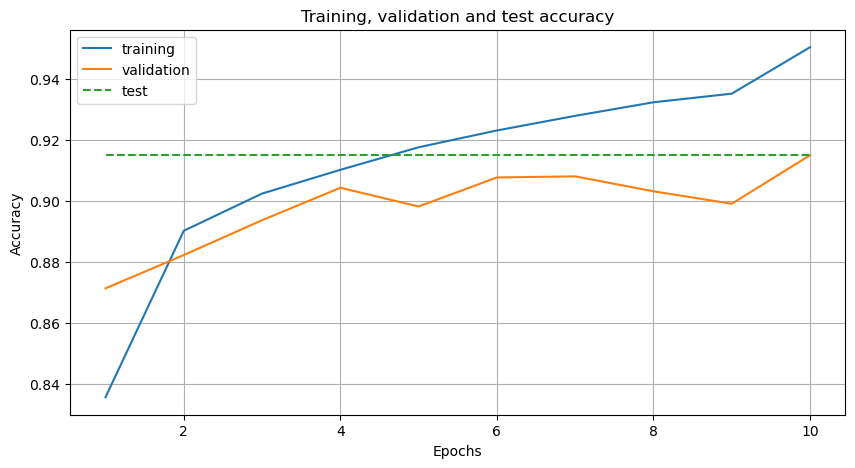

In [140]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), final_result['train_accuracy_hist'], label='training')
plt.plot(range(1, 11), final_result['val_accuracy_hist'], label='validation')
plt.plot(range(1, 11), [test_accuracy] * 10, label='test', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training, validation and test accuracy')
plt.legend()
plt.grid(True)
plt.show()

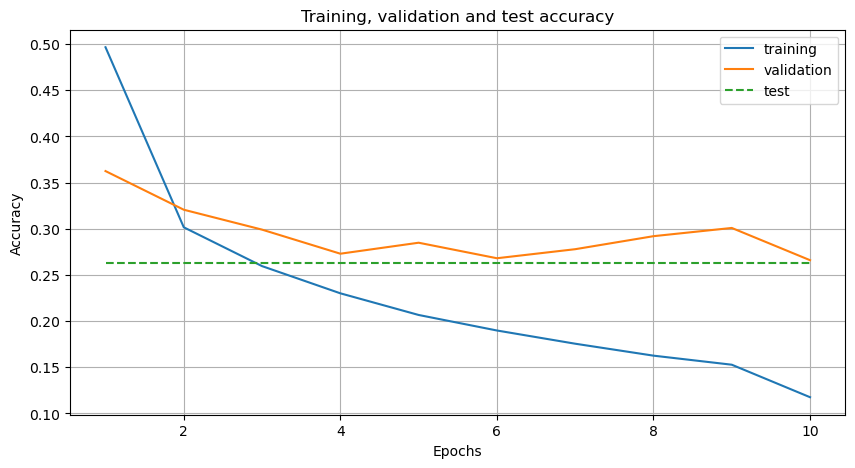

In [146]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), final_result['train_loss_hist'], label='training')
plt.plot(range(1, 11), final_result['val_loss_hist'], label='validation')
plt.plot(range(1, 11), [test_loss] * 10, label='test', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training, validation and test loss')
plt.legend()
plt.grid(True)
plt.show()

In [147]:
y_true = final_test_result['test_labels']
y_pred = final_test_result['test_predicted']
classes = dataset.classes

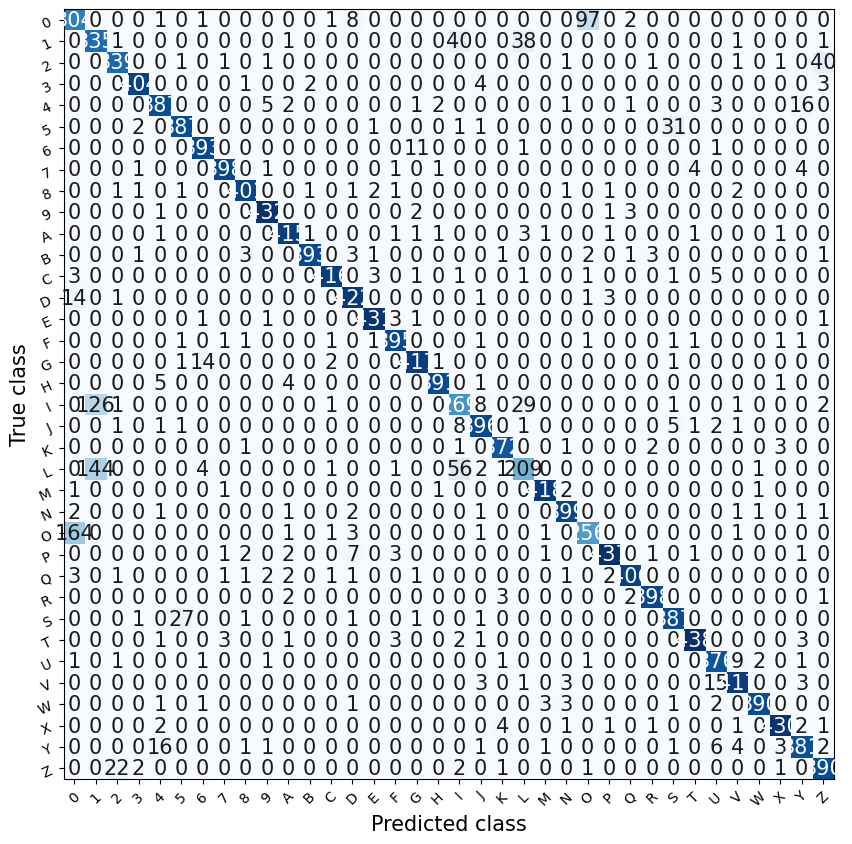

In [165]:
metric = MulticlassConfusionMatrix(num_classes=36)
metric.update(y_pred, y_true)
fig_, ax_ = plt.subplots(figsize=(10, 10))
conf_matrix_plot = metric.plot(labels=classes, cmap='Blues', ax=ax_)

In [107]:
print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

           0       0.65      0.64      0.65       414
           1       0.58      0.78      0.66       417
           2       0.92      0.93      0.92       386
           3       0.98      0.96      0.97       414
           4       0.92      0.94      0.93       418
           5       0.93      0.91      0.92       423
           6       0.97      0.97      0.97       406
           7       0.98      0.98      0.98       410
           8       0.95      0.97      0.96       413
           9       0.98      0.98      0.98       439
           A       0.97      0.96      0.97       427
           B       0.99      0.97      0.98       409
           C       0.96      0.97      0.97       432
           D       0.95      0.97      0.96       442
           E       0.99      0.98      0.98       438
           F       0.97      0.97      0.97       406
           G       0.96      0.95      0.95       436
           H       0.98    

In [166]:
y_outputs = final_test_result['test_outputs']

In [167]:
roc = MulticlassROC(num_classes=36)
fpr, tpr, thresholds = roc(y_outputs, y_true.to(dtype=torch.long))

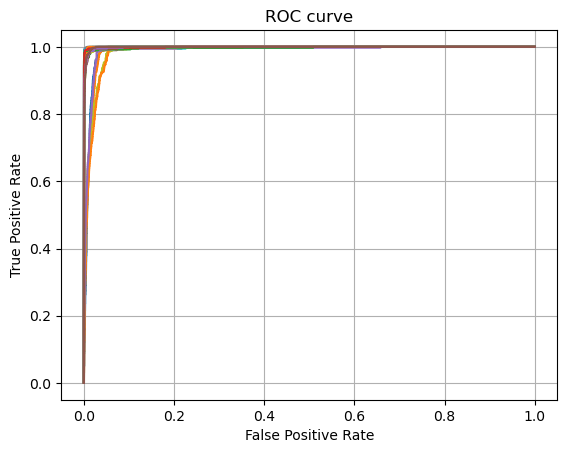

In [168]:
for i in range(len(fpr)):  
    plt.plot(fpr[i], tpr[i])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.grid()
plt.show()

### Reference
- Assignment 2 part 1 preprocessing, test
- Assignment 2 part 2 preprocessing, optimization
- https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html#imagefolder
- https://medium.com/jun94-devpblog/pytorch-1-transform-imagefolder-dataloader-7f75f0a460c0
- https://www.programcreek.com/python/example/105102/torchvision.datasets.ImageFolder
- https://pytorch.org/vision/0.8/transforms.html?highlight=transforms
- https://pytorch.org/tutorials/beginner/basics/data_tutorial.html
- https://github.com/TylerYep/torchinfo
- https://lightning.ai/docs/torchmetrics/stable/classification/accuracy.html
- https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html
- https://lightning.ai/docs/torchmetrics/stable/classification/confusion_matrix.html
- https://matplotlib.org/stable/users/explain/colors/colormaps.html
- https://lightning.ai/docs/torchmetrics/stable/classification/roc.html